In [30]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import matplotlib.pyplot as plt


In [31]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)

In [32]:
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [33]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289441042'}


# Reframe the data

In [34]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289435042
Added column for sensor: 289423042
Added column for sensor: 289429042
Added column for sensor: 289441042
Finished!
                           289435042    unixtime  289423042  289429042  \
time                                                                     
2021-03-03 23:15:00+00:00    3606.54  1614813300        NaN    1605.77   
2021-03-03 23:30:00+00:00        NaN  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    3556.45  1614815100     902.27    1602.34   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN    1611.26   
2021-03-04 00:15:00+00:00        NaN  1614816900     901.96    1614.24   

                           289441042  
time                                  
2021-03-03 23:15:00+00:00    4797.72  
2021-03-03 23:30:00+00:00    4717.80  
2021-03-03 23:45:00+00:00    4745.36  
2021-03-04 00:00:00+00:00        NaN  
2021-03-04 00:15:00+00:00        NaN  


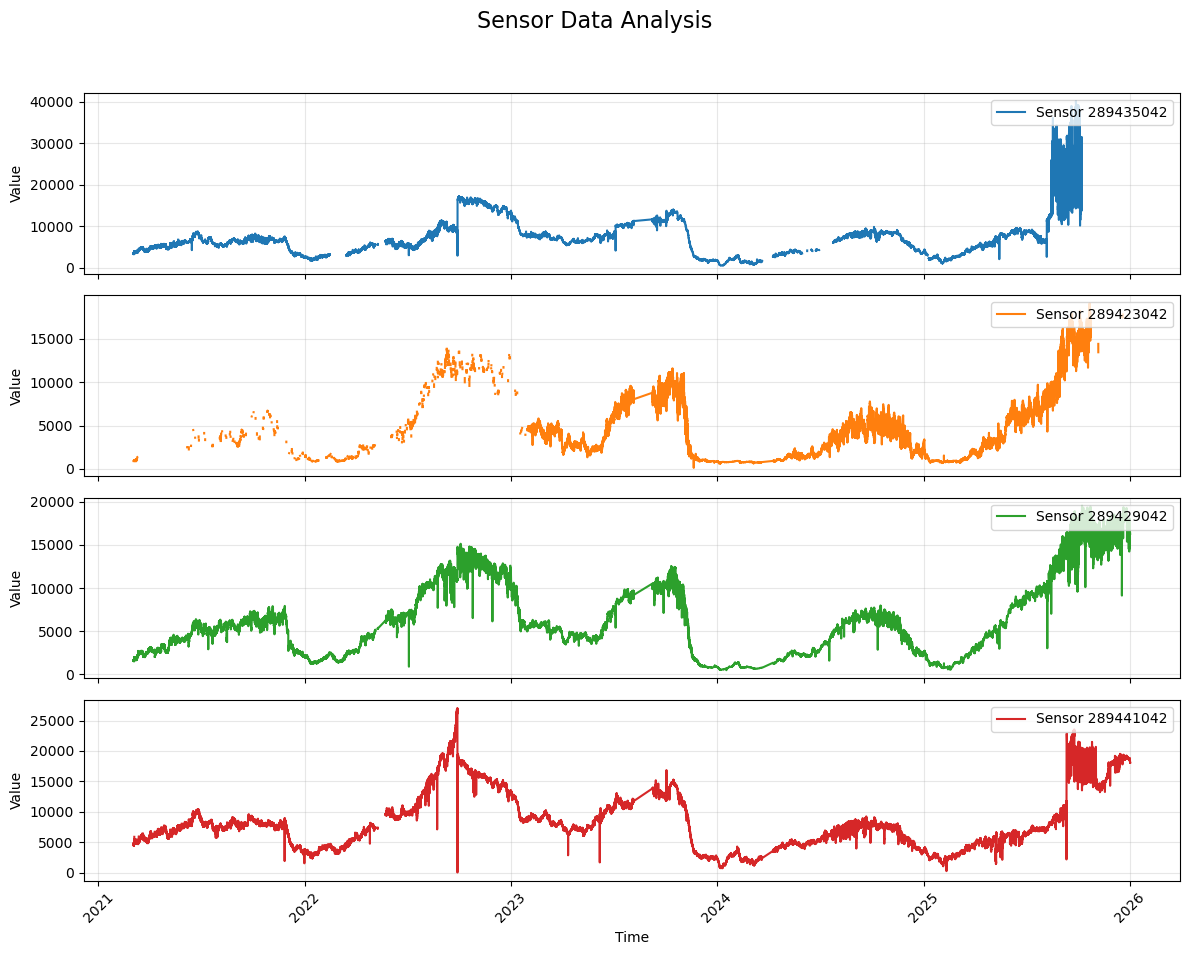

In [35]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, sensor in enumerate(sensors):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Feature Engineering

In [36]:
data = final_df.copy()
target_sensor = '289441042'

# 1. Time-based features (Seasonality)
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek

# 2. Lag features for the TARGET (Sensor 4)
    # We look back 15m, 1h, and 24h
for lag in [1, 4, 96]:
    data[f'{target_sensor}_lag_{lag}'] = data[target_sensor].shift(lag)

# 3. Spatial Lag features for NEIGHBORS (Sensors 1, 2, 3)
# These provide "upstream" context
neighbors = [c for c in final_df.columns if c != target_sensor]

for s in neighbors:
        data[f'{s}_lag_1'] = data[s].shift(1)  # What happened 15 mins ago upstream?
        data[f'{s}_lag_4'] = data[s].shift(4)  # What happened 1 hour ago upstream?

# 4. Rolling statistics (Trend)
data['rolling_mean_6h'] = data[target_sensor].shift(1).rolling(window=24).mean()
data.dropna(inplace=True)
df_featured = data.copy()

# Data preparation

In [ ]:
# Split based on your specific dates
train_data = df_featured[:'2025-08-31'] # all data up to August 2025
test_data = df_featured['2025-09-01':'2025-09-30'] # ground truth month



X_train = train_data.drop(columns=sensors)  # Drop original sensor columns
y_train = train_data[target_sensor]

X_test = test_data.drop(columns=sensors)
y_test = test_data[target_sensor]

In [49]:
#print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
#print(X_train.head())
print(X_test.head())



Testing data shape: (0, 15)
Empty DataFrame
Columns: [unixtime, hour, day_of_week, 289441042_lag_1, 289441042_lag_4, 289441042_lag_96, 289435042_lag_1, 289435042_lag_4, unixtime_lag_1, unixtime_lag_4, 289423042_lag_1, 289423042_lag_4, 289429042_lag_1, 289429042_lag_4, rolling_mean_6h]
Index: []


# Actual training 

In [39]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=64,
    n_jobs=-1,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse'
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3346
[LightGBM] [Info] Number of data points in the train set: 82688, number of used features: 15


ValueError: Input data must be 2 dimensional and non empty.

# Forecast and Compare

forecast = model.predict(X_test)

mae = mean_absolute_error(y_test, forecast)
print(f"January 2026 Forecast MAE: {mae:.4f} units of conductivity")